In [37]:
import sys
import os

# Get the path of the notebook's parent folder (project root)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
print("Project root added to sys.path:", PROJECT_ROOT)

import sys
import os
import pandas as pd
from datetime import datetime, timedelta

# Add project root to sys.path so we can import our modules
PROJECT_ROOT = os.getcwd()  # adjust if notebook is in a subfolder
sys.path.insert(0, PROJECT_ROOT)

# Import the merge function
from src.ingestion.merge_data import merge_historical_data

# Your AQICN token
token = "361cf32474f50ec4ff9f3f677392739e1bfd8384"

# Fetch merged historical data
historical_df = merge_historical_data(city="karachi", token=token)

# Quick sanity check
print("Merged historical data loaded. Shape:", historical_df.shape)
display(historical_df.head())


[2026-02-03 01:25:04,144] [INFO] src.ingestion.merge_data - Fetching and merging historical data for karachi
[2026-02-03 01:25:04,159] [INFO] src.ingestion.station_resolver - Resolving AQICN station


Project root added to sys.path: c:\Users\NAWAB AHMAD\aqi-forecasting-mlops


[2026-02-03 01:25:05,696] [INFO] src.ingestion.station_resolver - Station resolved
[2026-02-03 01:25:05,705] [INFO] src.ingestion.openmeteo_historical_client - Fetching historical AQI from Open-Meteo
[2026-02-03 01:25:06,878] [INFO] src.ingestion.openmeteo_historical_client - Historical AQI normalized
[2026-02-03 01:25:07,852] [INFO] src.ingestion.openmeteo_weather_historical_client - Fetching historical weather from Open-Meteo
[2026-02-03 01:25:08,984] [INFO] src.ingestion.openmeteo_weather_historical_client - Historical weather normalized
[2026-02-03 01:25:09,401] [INFO] src.ingestion.merge_data - Merged historical data shape: (2904, 19)


Merged historical data loaded. Shape: (2904, 19)


,city_x,event_timestamp,source_x,ingested_at_x,pm25_pollutants,pm10_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,co_pollutants,city_y,source_y,ingested_at_y,temperature_weather,humidity_weather,wind_speed_weather,wind_direction_weather,pressure_weather,precipitation_weather
0,karachi,2025-10-05 00:00:00+00:00,open-meteo,2026-02-02 20:25:06.838484+00:00,12.4,16.5,11.2,7.3,44.0,163.0,karachi,open-meteo-weather,2026-02-02 20:25:08.976573+00:00,26.5,94.0,5.7,257.0,1007.0,0.0
1,karachi,2025-10-05 01:00:00+00:00,open-meteo,2026-02-02 20:25:06.838484+00:00,13.8,18.3,13.6,9.5,46.0,198.0,karachi,open-meteo-weather,2026-02-02 20:25:08.976573+00:00,26.7,93.0,6.4,241.0,1007.2,0.1
2,karachi,2025-10-05 02:00:00+00:00,open-meteo,2026-02-02 20:25:06.838484+00:00,18.3,23.5,16.7,12.4,48.0,242.0,karachi,open-meteo-weather,2026-02-02 20:25:08.976573+00:00,27.0,90.0,7.2,242.0,1007.7,0.0
3,karachi,2025-10-05 03:00:00+00:00,open-meteo,2026-02-02 20:25:06.838484+00:00,18.2,25.0,17.7,14.7,54.0,271.0,karachi,open-meteo-weather,2026-02-02 20:25:08.976573+00:00,28.1,82.0,9.7,242.0,1008.2,0.1
4,karachi,2025-10-05 04:00:00+00:00,open-meteo,2026-02-02 20:25:06.838484+00:00,17.1,24.6,14.5,15.7,65.0,270.0,karachi,open-meteo-weather,2026-02-02 20:25:08.976573+00:00,29.1,76.0,10.7,243.0,1008.6,0.0


Inspect Missing Values and Data Types

In [38]:
# Step 1: Inspect missing values and data types
print("=== Data Types ===")
print(historical_df.dtypes)

print("\n=== Missing Values ===")
missing_counts = historical_df.isna().sum()
missing_percent = (missing_counts / len(historical_df)) * 100
missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)
display(missing_df)


=== Data Types ===
city_x                                 object
event_timestamp           datetime64[ns, UTC]
source_x                               object
ingested_at_x             datetime64[ns, UTC]
pm25_pollutants                       float64
pm10_pollutants                       float64
no2_pollutants                        float64
so2_pollutants                        float64
o3_pollutants                         float64
co_pollutants                         float64
city_y                                 object
source_y                               object
ingested_at_y             datetime64[ns, UTC]
temperature_weather                   float64
humidity_weather                      float64
wind_speed_weather                    float64
wind_direction_weather                float64
pressure_weather                      float64
precipitation_weather                 float64
dtype: object

=== Missing Values ===


,missing_count,missing_percent
city_x,0,0.0
city_y,0,0.0
pressure_weather,0,0.0
wind_direction_weather,0,0.0
wind_speed_weather,0,0.0
humidity_weather,0,0.0
temperature_weather,0,0.0
ingested_at_y,0,0.0
source_y,0,0.0
co_pollutants,0,0.0


Basic Cleaning / Column Selection

In [39]:
# Step 2: Select relevant columns for modeling
columns_to_keep = [
    "event_timestamp",
    "pm25_pollutants", "pm10_pollutants", "no2_pollutants",
    "so2_pollutants", "o3_pollutants", "co_pollutants",
    "temperature_weather", "humidity_weather", "wind_speed_weather",
    "wind_direction_weather", "pressure_weather", "precipitation_weather"
]

preprocessed_df = historical_df[columns_to_keep].copy()

# Optional: rename columns for clarity (snake_case standard)
preprocessed_df.rename(columns={
    "pm25_pollutants": "pm25",
    "pm10_pollutants": "pm10",
    "temperature_weather": "temperature",
    "humidity_weather": "humidity",
    "wind_speed_weather": "wind_speed",
    "wind_direction_weather": "wind_direction",
    "pressure_weather": "pressure",
    "precipitation_weather": "precipitation"
}, inplace=True)

# Quick check
print("Columns after basic cleaning:")
print(preprocessed_df.columns)
display(preprocessed_df.head())


Columns after basic cleaning:
Index(['event_timestamp', 'pm25', 'pm10', 'no2_pollutants', 'so2_pollutants',
       'o3_pollutants', 'co_pollutants', 'temperature', 'humidity',
       'wind_speed', 'wind_direction', 'pressure', 'precipitation'],
      dtype='object')


,event_timestamp,pm25,pm10,no2_pollutants,so2_pollutants,o3_pollutants,co_pollutants,temperature,humidity,wind_speed,wind_direction,pressure,precipitation
0,2025-10-05 00:00:00+00:00,12.4,16.5,11.2,7.3,44.0,163.0,26.5,94.0,5.7,257.0,1007.0,0.0
1,2025-10-05 01:00:00+00:00,13.8,18.3,13.6,9.5,46.0,198.0,26.7,93.0,6.4,241.0,1007.2,0.1
2,2025-10-05 02:00:00+00:00,18.3,23.5,16.7,12.4,48.0,242.0,27.0,90.0,7.2,242.0,1007.7,0.0
3,2025-10-05 03:00:00+00:00,18.2,25.0,17.7,14.7,54.0,271.0,28.1,82.0,9.7,242.0,1008.2,0.1
4,2025-10-05 04:00:00+00:00,17.1,24.6,14.5,15.7,65.0,270.0,29.1,76.0,10.7,243.0,1008.6,0.0


Visualize Outliers

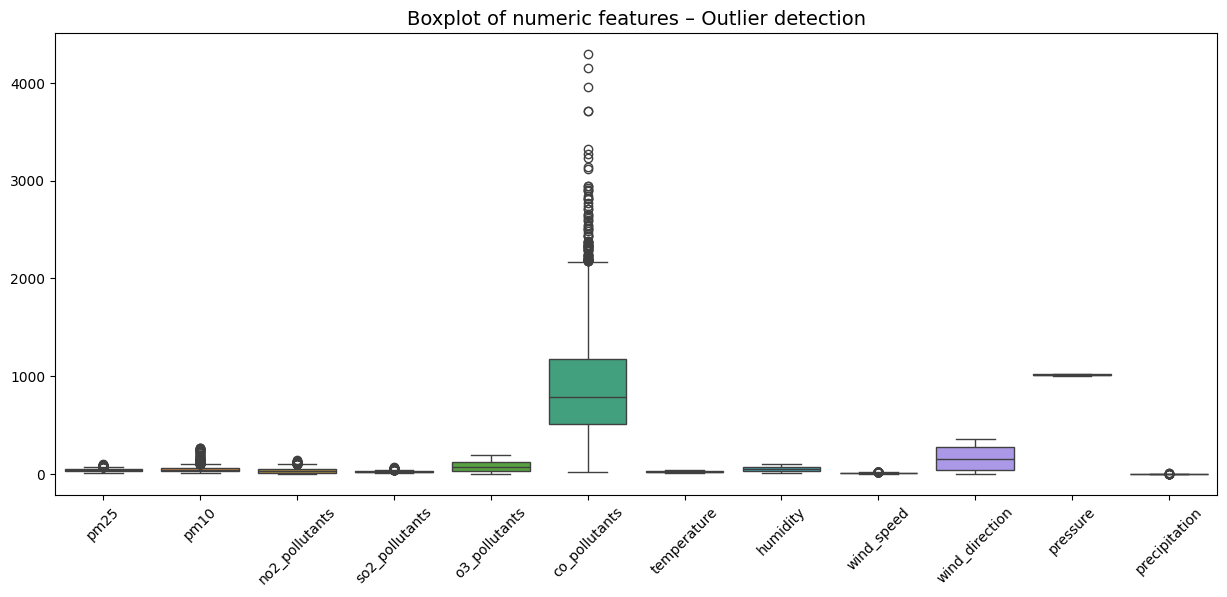

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = preprocessed_df.drop(columns=["event_timestamp"]).columns

plt.figure(figsize=(15, 6))
sns.boxplot(data=preprocessed_df[numeric_features])
plt.title("Boxplot of numeric features – Outlier detection", fontsize=14)
plt.xticks(rotation=45)
plt.show()


Selective Outlier Capping

In [41]:
import numpy as np
import pandas as pd

def cap_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    """
    Caps outliers in a numeric pandas Series using the IQR method.

    Parameters
    ----------
    series : pd.Series
        Numeric feature column
    factor : float, optional
        IQR multiplier (default = 1.5)

    Returns
    -------
    pd.Series
        Series with capped outliers
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    return series.clip(lower=lower_bound, upper=upper_bound)


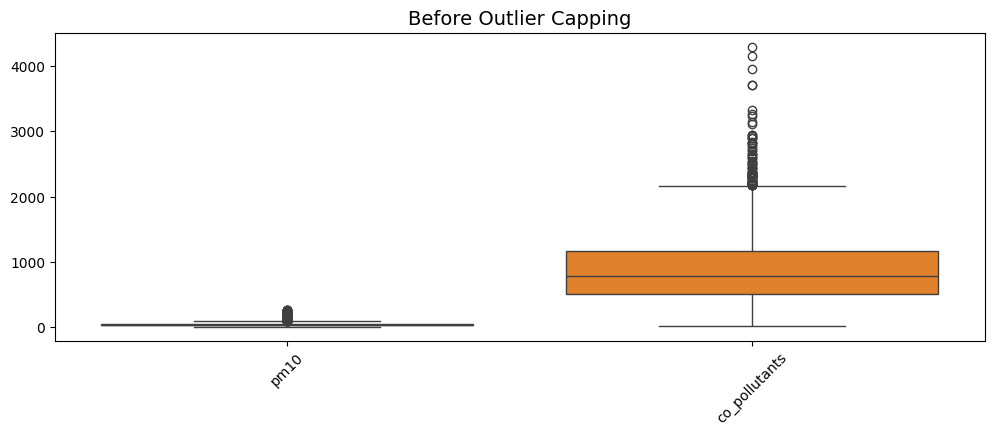

In [42]:
features_to_cap = ["pm10", "co_pollutants"]

plt.figure(figsize=(12, 4))
sns.boxplot(data=preprocessed_df[features_to_cap])
plt.title("Before Outlier Capping", fontsize=14)
plt.xticks(rotation=45)
plt.show()


In [43]:
preprocessed_df_capped = preprocessed_df.copy()

for feature in features_to_cap:
    preprocessed_df_capped[feature] = cap_outliers_iqr(
        preprocessed_df_capped[feature]
    )


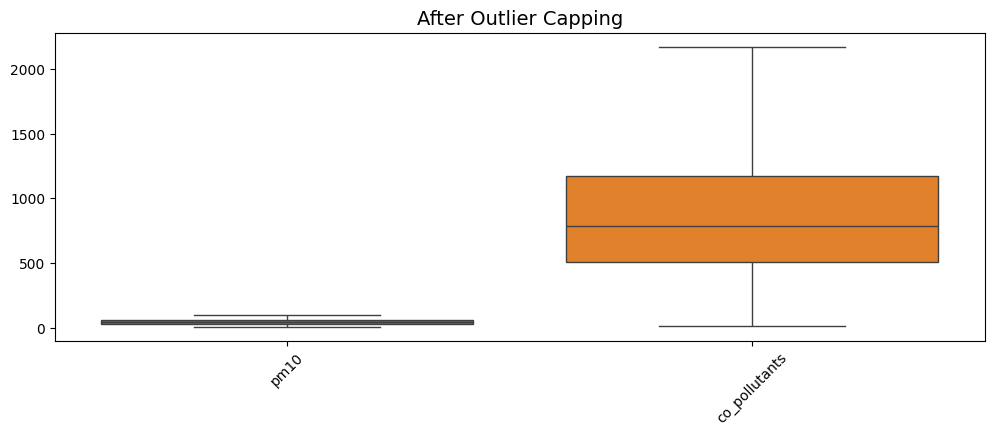

In [44]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=preprocessed_df_capped[features_to_cap])
plt.title("After Outlier Capping", fontsize=14)
plt.xticks(rotation=45)
plt.show()


In [45]:
summary = pd.DataFrame({
    "before_max": preprocessed_df[features_to_cap].max(),
    "after_max": preprocessed_df_capped[features_to_cap].max()
})

display(summary)


,before_max,after_max
pm10,262.6,96.7625
co_pollutants,4295.0,2169.1250


Time-Based Feature Engineering

Extract Basic Time Features

In [46]:
# Ensure event_timestamp is in datetime format
preprocessed_df_capped['event_timestamp'] = pd.to_datetime(preprocessed_df_capped['event_timestamp'])

# Extract time features
preprocessed_df_capped['hour'] = preprocessed_df_capped['event_timestamp'].dt.hour
preprocessed_df_capped['day'] = preprocessed_df_capped['event_timestamp'].dt.day
preprocessed_df_capped['weekday'] = preprocessed_df_capped['event_timestamp'].dt.weekday  # Monday=0
preprocessed_df_capped['month'] = preprocessed_df_capped['event_timestamp'].dt.month
preprocessed_df_capped['is_weekend'] = preprocessed_df_capped['weekday'].isin([5,6]).astype(int)  # Saturday/Sunday

# Quick check
display(preprocessed_df_capped[['event_timestamp','hour','day','weekday','month','is_weekend']].head(100))


,event_timestamp,hour,day,weekday,month,is_weekend
0,2025-10-05 00:00:00+00:00,0,5,6,10,1
1,2025-10-05 01:00:00+00:00,1,5,6,10,1
2,2025-10-05 02:00:00+00:00,2,5,6,10,1
3,2025-10-05 03:00:00+00:00,3,5,6,10,1
4,2025-10-05 04:00:00+00:00,4,5,6,10,1
...,...,...,...,...,...,...
95,2025-10-08 23:00:00+00:00,23,8,2,10,0
96,2025-10-09 00:00:00+00:00,0,9,3,10,0
97,2025-10-09 01:00:00+00:00,1,9,3,10,0
98,2025-10-09 02:00:00+00:00,2,9,3,10,0


Quick EDA on Time Features

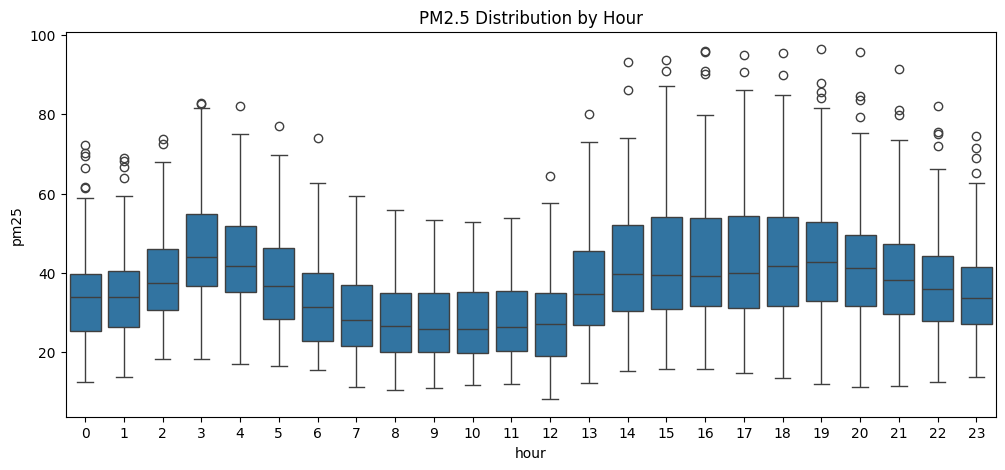

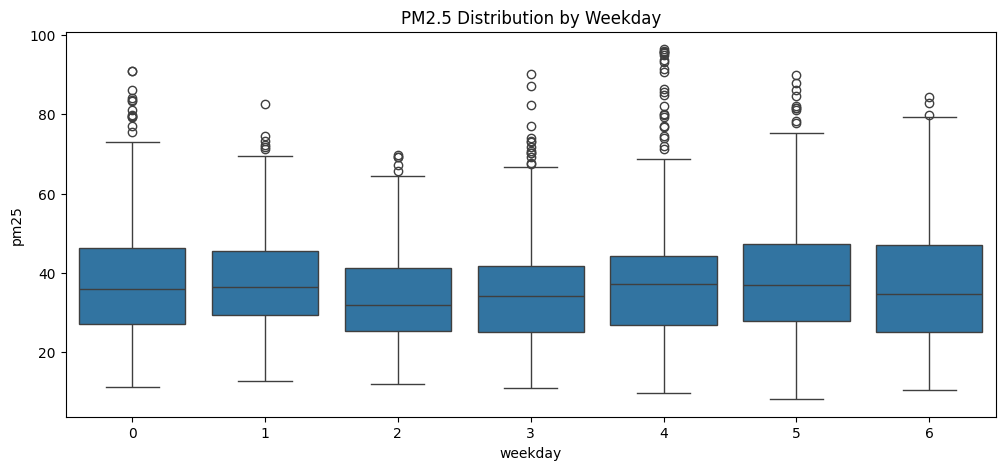

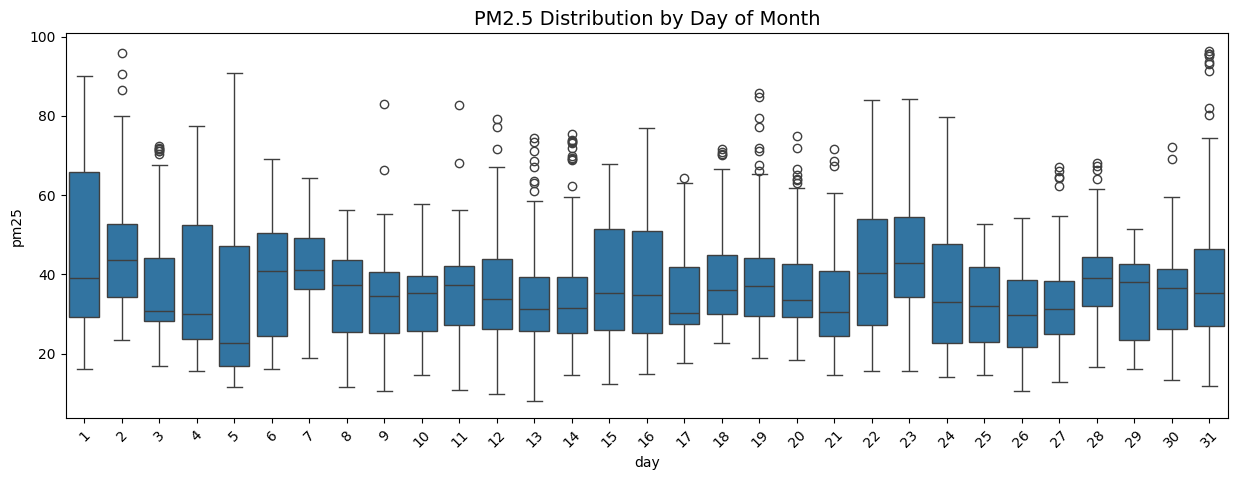

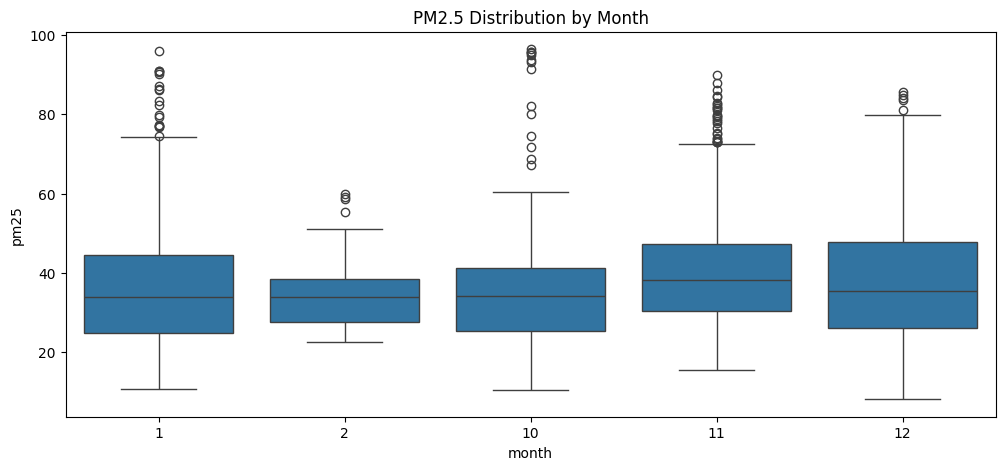

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# PM2.5 vs Hour
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='pm25', data=preprocessed_df_capped)
plt.title("PM2.5 Distribution by Hour")
plt.show()

# PM2.5 vs Weekday
plt.figure(figsize=(12,5))
sns.boxplot(x='weekday', y='pm25', data=preprocessed_df_capped)
plt.title("PM2.5 Distribution by Weekday")
plt.show()

# PM2.5 vs Day of Month
plt.figure(figsize=(15,5))
sns.boxplot(x='day', y='pm25', data=preprocessed_df_capped)
plt.title("PM2.5 Distribution by Day of Month", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# PM2.5 vs Month
plt.figure(figsize=(12,5))
sns.boxplot(x='month', y='pm25', data=preprocessed_df_capped)
plt.title("PM2.5 Distribution by Month")
plt.show()


eda_time_features_pro

- Include hour, weekday, month, and day-of-month
- Include optional rolling averages for smoother trends
- Be modular, reusable, layman-friendly, and consistent

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def eda_time_features_layman(
    df, 
    features=['pm25','pm10','co_pollutants'], 
    rolling_window=3, 
    show_heatmap=True
):
    """
    Layman-friendly, industry-level EDA for AQI data.
    
    Features:
    - Hourly, weekday, monthly, day-of-month trends
    - Rolling averages for smooth trends
    - Heatmap for weekday vs hour
    - Annotations for easy interpretation
    - Color coding for intuitive understanding
    
    Args:
        df: DataFrame with ['hour','weekday','day','month'] + pollutant features
        features: list of pollutants
        rolling_window: window for rolling average
        show_heatmap: show heatmap for weekday vs hour
    """
    
    # AQI thresholds for PM2.5 (example, can adjust)
    aqi_thresholds = {"Good": 0-50, "Moderate": 51-100, "Unhealthy": 101-200, "Hazardous": 201}
    
    for feature in features:
        print(f"\n=== EDA for {feature.upper()} ===\n")
        
        # ---------------- Hourly Trend ----------------
        hourly_avg = df.groupby('hour')[feature].mean()
        hourly_std = df.groupby('hour')[feature].std()
        plt.figure(figsize=(12,4))
        plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='dodgerblue', label=f'Mean {feature.upper()}')
        plt.fill_between(hourly_avg.index, hourly_avg-hourly_std, hourly_avg+hourly_std,
                         color='dodgerblue', alpha=0.2, label='±1 Std Dev')
        if rolling_window:
            plt.plot(hourly_avg.index, hourly_avg.rolling(rolling_window,min_periods=1).mean(),
                     color='red', linestyle='--', label=f'Rolling {rolling_window}')
        
        # Annotate max and min
        max_hour = hourly_avg.idxmax()
        max_val = hourly_avg.max()
        plt.scatter(max_hour, max_val, color='red', s=100)
        plt.text(max_hour, max_val+5, f'Max: {max_val:.1f}', color='red', ha='center')
        
        plt.title(f"{feature.upper()} – Hourly Trend\n(Darker = More Pollution, Red = Peak)", fontsize=12)
        plt.xlabel("Hour of Day")
        plt.ylabel(f"{feature.upper()} Concentration")
        plt.xticks(range(0,24))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
        
        # ---------------- Weekday Trend ----------------
        weekday_avg = df.groupby('weekday')[feature].mean()
        weekday_std = df.groupby('weekday')[feature].std()
        plt.figure(figsize=(10,4))
        colors = ['green' if x < 50 else 'orange' if x<100 else 'red' for x in weekday_avg.values]
        plt.bar(weekday_avg.index, weekday_avg.values, yerr=weekday_std.values, capsize=5, color=colors)
        plt.xlabel("Weekday (0=Mon, 6=Sun)")
        plt.ylabel(f"{feature.upper()} Concentration")
        plt.title(f"{feature.upper()} – Weekday Trend (Color = Pollution Level)")
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
        # ---------------- Monthly Trend ----------------
        monthly_avg = df.groupby('month')[feature].mean()
        plt.figure(figsize=(12,4))
        plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='purple', linewidth=2)
        plt.fill_between(monthly_avg.index, monthly_avg*0.9, monthly_avg*1.1, color='purple', alpha=0.2)
        plt.title(f"{feature.upper()} – Monthly Trend (Seasonal Changes)", fontsize=12)
        plt.xlabel("Month")
        plt.ylabel(f"{feature.upper()} Concentration")
        plt.grid(alpha=0.3)
        plt.show()
        
        # ---------------- Day-of-Month Trend ----------------
        day_avg = df.groupby('day')[feature].mean()
        plt.figure(figsize=(12,4))
        plt.plot(day_avg.index, day_avg.values, marker='o', color='darkorange')
        plt.title(f"{feature.upper()} – Day-of-Month Trend", fontsize=12)
        plt.xlabel("Day of Month")
        plt.ylabel(f"{feature.upper()} Concentration")
        plt.grid(alpha=0.3)
        plt.show()
        
        # ---------------- Heatmap ----------------
        if show_heatmap:
            heatmap_data = df.pivot_table(index='weekday', columns='hour', values=feature, aggfunc='mean')
            plt.figure(figsize=(15,4))
            sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False)
            plt.title(f"{feature.upper()} – Heatmap: Weekday vs Hour (Darker = Higher Pollution)")
            plt.xlabel("Hour of Day")
            plt.ylabel("Weekday (0=Mon,6=Sun)")
            plt.show()



=== EDA for PM25 ===



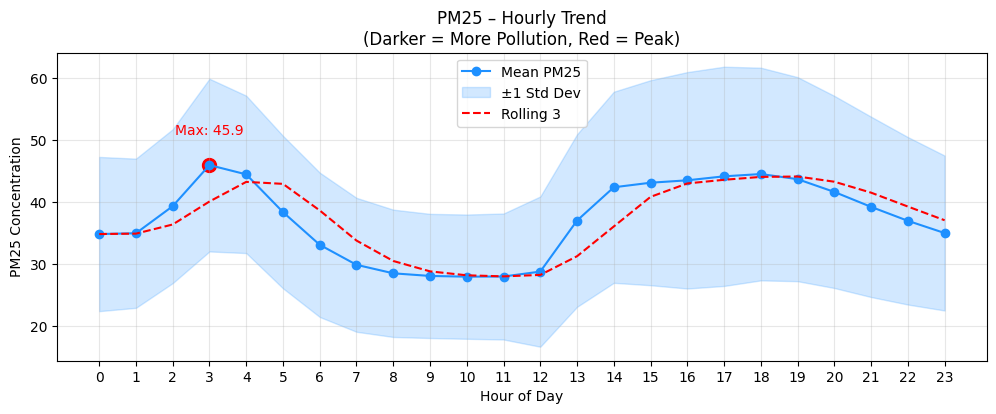

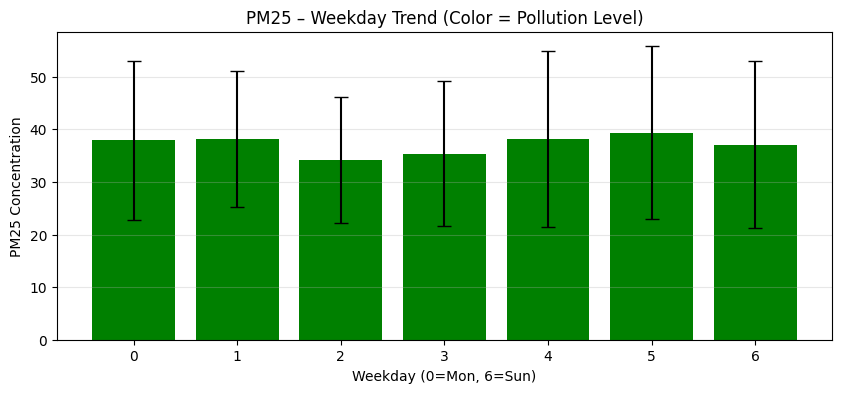

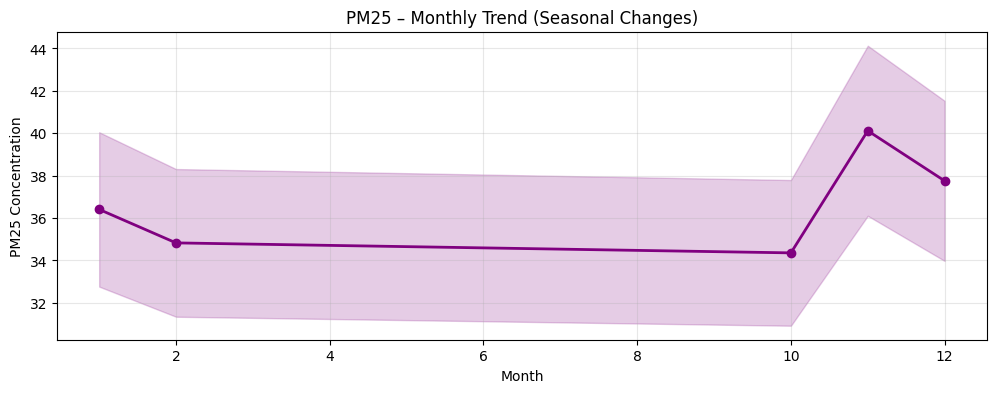

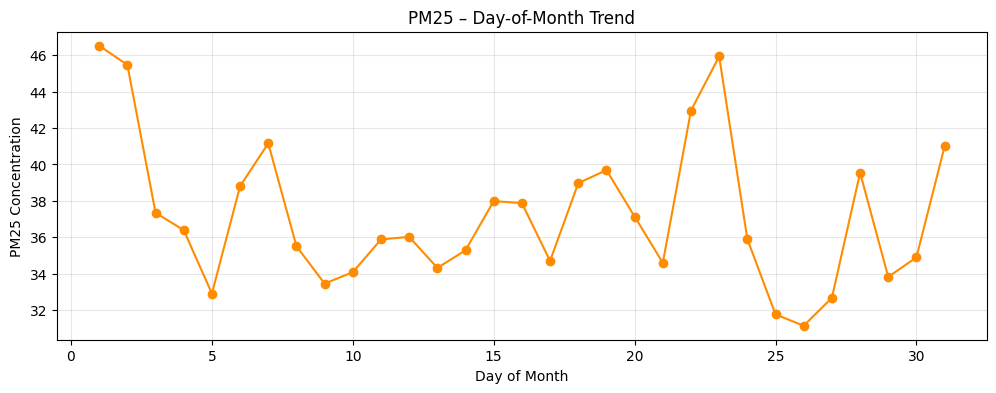

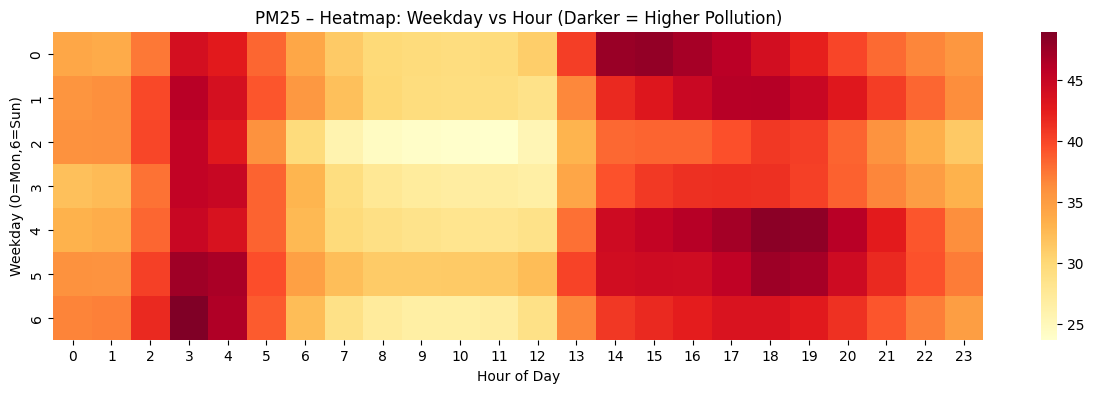


=== EDA for PM10 ===



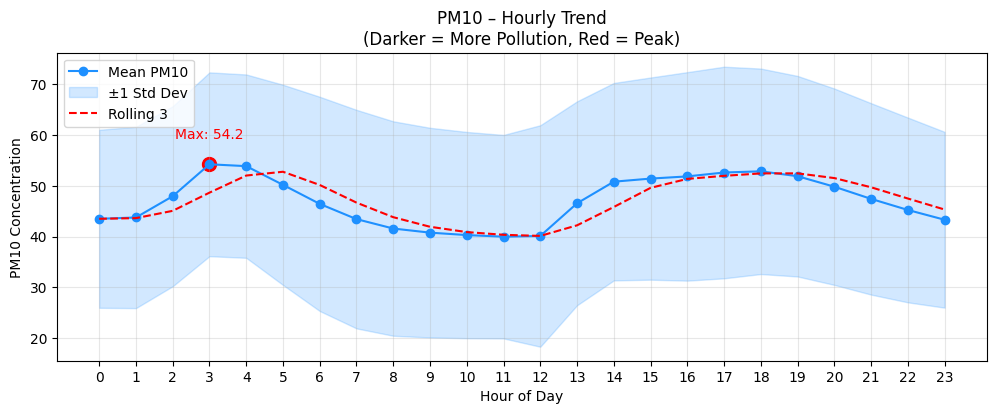

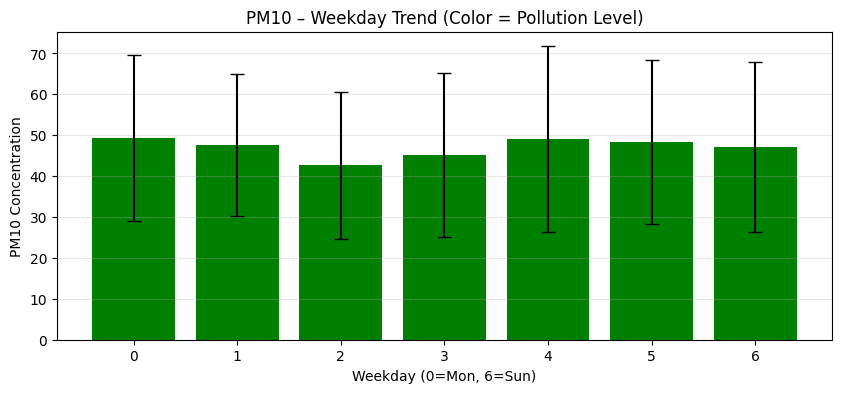

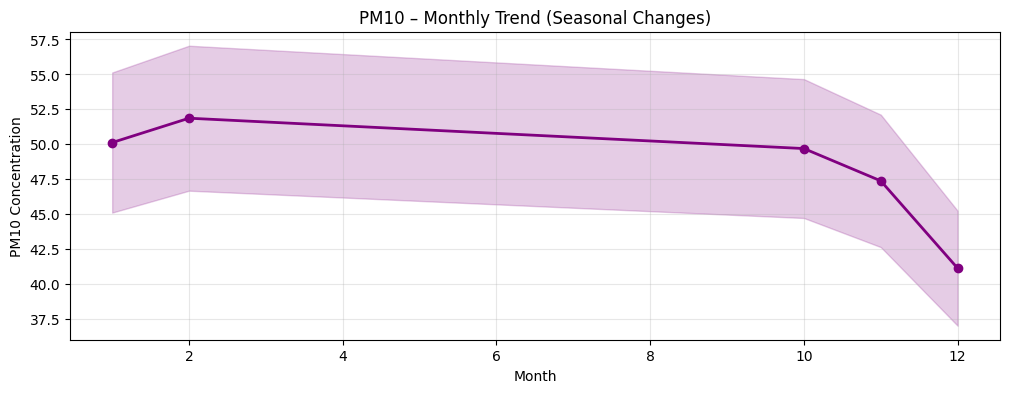

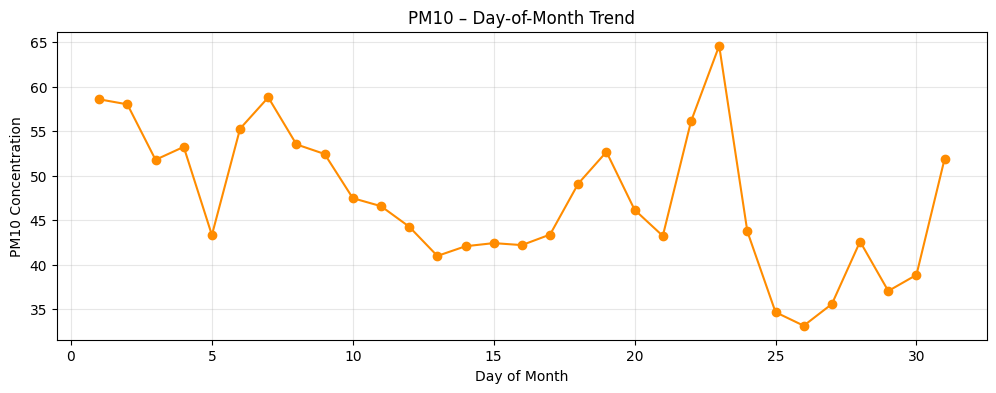

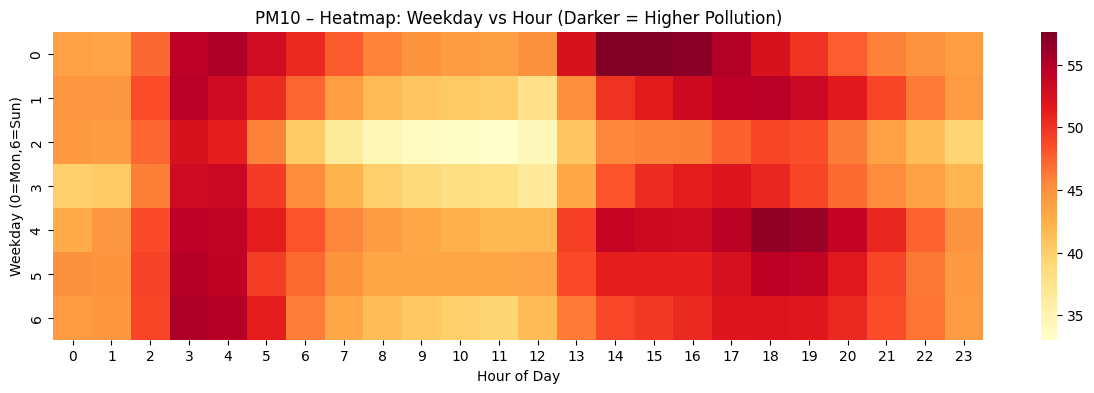


=== EDA for CO_POLLUTANTS ===



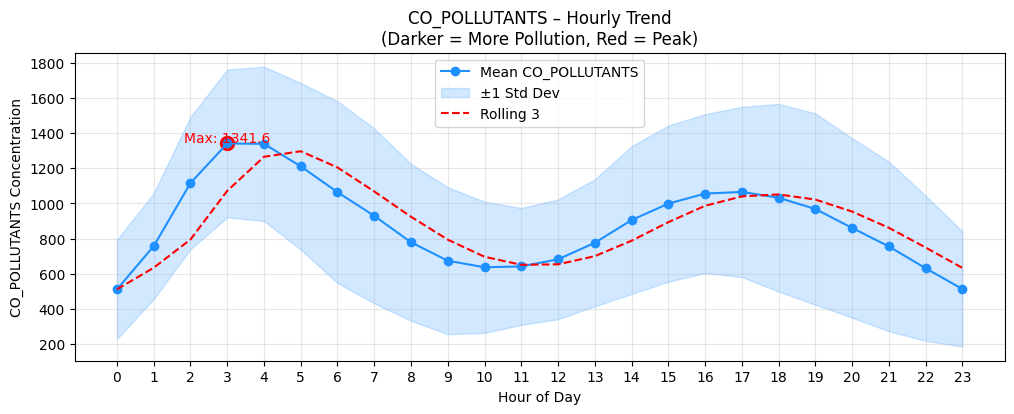

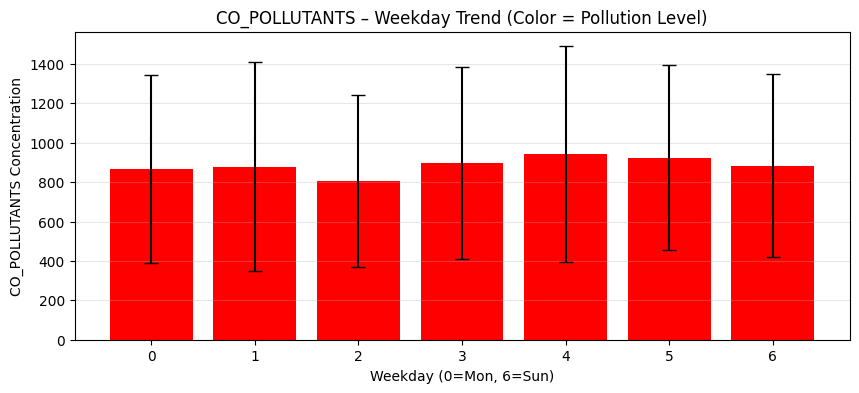

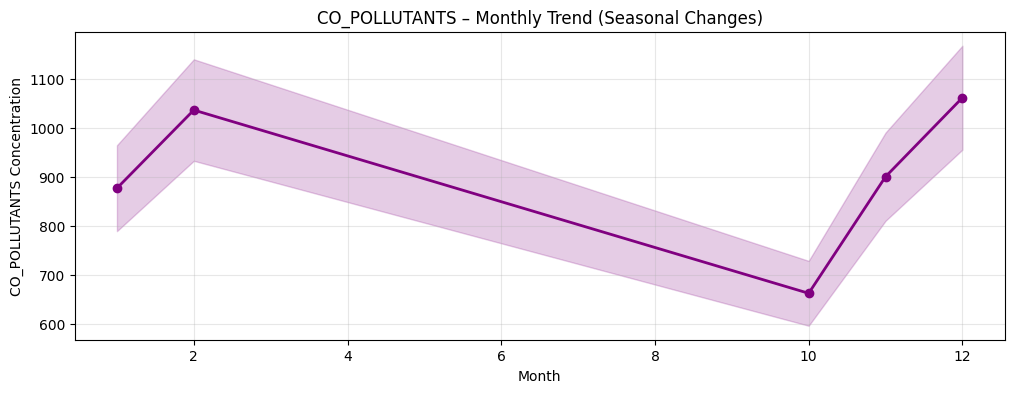

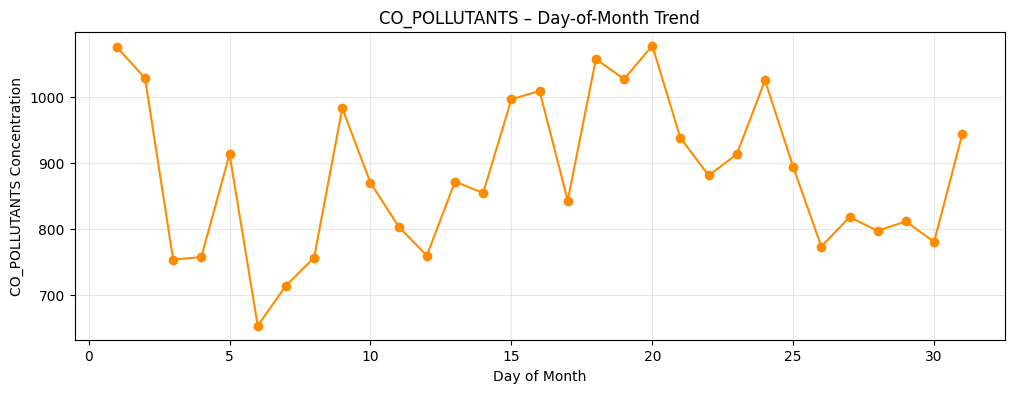

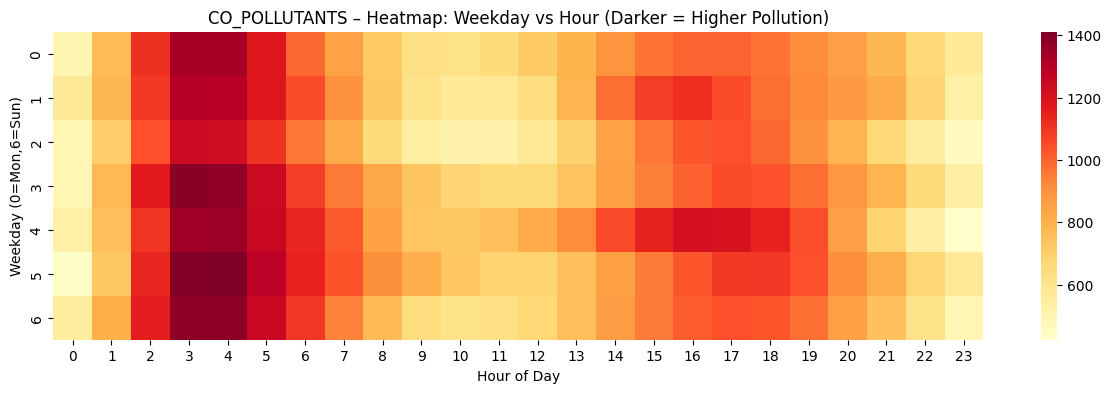

In [49]:
eda_time_features_layman(
    preprocessed_df_capped,
    features=['pm25','pm10','co_pollutants'],
    rolling_window=3,
    show_heatmap=True
)


Add day and is_weekend Features

In [51]:
# Ensure event_timestamp is in datetime format
preprocessed_df_capped['event_timestamp'] = pd.to_datetime(preprocessed_df_capped['event_timestamp'])

# Add day of month
preprocessed_df_capped['day'] = preprocessed_df_capped['event_timestamp'].dt.day

# Add is_weekend feature
preprocessed_df_capped['is_weekend'] = preprocessed_df_capped['weekday'].apply(lambda x: 1 if x >=5 else 0)

# Quick check
display(preprocessed_df_capped[['event_timestamp', 'hour', 'weekday', 'day', 'is_weekend']].head(101))


,event_timestamp,hour,weekday,day,is_weekend
0,2025-10-05 00:00:00+00:00,0,6,5,1
1,2025-10-05 01:00:00+00:00,1,6,5,1
2,2025-10-05 02:00:00+00:00,2,6,5,1
3,2025-10-05 03:00:00+00:00,3,6,5,1
4,2025-10-05 04:00:00+00:00,4,6,5,1
...,...,...,...,...,...
96,2025-10-09 00:00:00+00:00,0,3,9,0
97,2025-10-09 01:00:00+00:00,1,3,9,0
98,2025-10-09 02:00:00+00:00,2,3,9,0
99,2025-10-09 03:00:00+00:00,3,3,9,0


Add Pollutant Change Rate Features

In [52]:
pollutant_features = ['pm25', 'pm10', 'co_pollutants', 'no2_pollutants', 'so2_pollutants', 'o3_pollutants']

for feature in pollutant_features:
    change_col = f'{feature}_change'
    preprocessed_df_capped[change_col] = preprocessed_df_capped[feature].diff()  # difference from previous row
    preprocessed_df_capped[change_col].fillna(0, inplace=True)  # first row will be NaN

# Quick check
display(preprocessed_df_capped[pollutant_features + [f'{f}_change' for f in pollutant_features]].head(10))


,pm25,pm10,co_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,pm25_change,pm10_change,co_pollutants_change,no2_pollutants_change,so2_pollutants_change,o3_pollutants_change
0,12.4,16.5,163.0,11.2,7.3,44.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.8,18.3,198.0,13.6,9.5,46.0,1.4,1.8,35.0,2.4,2.2,2.0
2,18.3,23.5,242.0,16.7,12.4,48.0,4.5,5.2,44.0,3.1,2.9,2.0
3,18.2,25.0,271.0,17.7,14.7,54.0,-0.1,1.5,29.0,1.0,2.3,6.0
4,17.1,24.6,270.0,14.5,15.7,65.0,-1.1,-0.4,-1.0,-3.2,1.0,11.0
5,16.6,24.1,253.0,9.2,16.0,79.0,-0.5,-0.5,-17.0,-5.3,0.3,14.0
6,16.9,24.4,237.0,5.2,15.7,89.0,0.3,0.3,-16.0,-4.0,-0.3,10.0
7,15.5,22.5,225.0,3.7,14.6,92.0,-1.4,-1.9,-12.0,-1.5,-1.1,3.0
8,14.6,21.5,213.0,3.5,13.0,91.0,-0.9,-1.0,-12.0,-0.2,-1.6,-1.0
9,14.0,21.1,207.0,3.9,11.8,88.0,-0.6,-0.4,-6.0,0.4,-1.2,-3.0


Lag Features

In [54]:
# Define lag hours
lag_hours = [1, 3, 6, 12, 24]  # adjust depending on data frequency

# Create lag features for each pollutant
for feature in pollutant_features:
    for lag in lag_hours:
        lag_col = f"{feature}_lag_{lag}"
        preprocessed_df_capped[lag_col] = preprocessed_df_capped[feature].shift(lag)
        
# Fill NaNs generated by shift with 0 (first few rows)
preprocessed_df_capped.fillna(0, inplace=True)

# Quick check
lag_cols = [f"{f}_lag_{l}" for f in pollutant_features for l in lag_hours]
display(preprocessed_df_capped[pollutant_features + lag_cols].head(100))


,pm25,pm10,co_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,pm25_lag_1,pm25_lag_3,pm25_lag_6,pm25_lag_12,...,so2_pollutants_lag_1,so2_pollutants_lag_3,so2_pollutants_lag_6,so2_pollutants_lag_12,so2_pollutants_lag_24,o3_pollutants_lag_1,o3_pollutants_lag_3,o3_pollutants_lag_6,o3_pollutants_lag_12,o3_pollutants_lag_24
0,12.4,16.5,163.0,11.2,7.3,44.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.8,18.3,198.0,13.6,9.5,46.0,12.4,0.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,44.0,0.0,0.0,0.0,0.0
2,18.3,23.5,242.0,16.7,12.4,48.0,13.8,0.0,0.0,0.0,...,9.5,0.0,0.0,0.0,0.0,46.0,0.0,0.0,0.0,0.0
3,18.2,25.0,271.0,17.7,14.7,54.0,18.3,12.4,0.0,0.0,...,12.4,7.3,0.0,0.0,0.0,48.0,44.0,0.0,0.0,0.0
4,17.1,24.6,270.0,14.5,15.7,65.0,18.2,13.8,0.0,0.0,...,14.7,9.5,0.0,0.0,0.0,54.0,46.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,38.9,92.4,200.0,42.7,16.9,10.0,45.2,49.6,41.9,43.2,...,19.2,21.6,20.9,25.9,13.9,6.0,2.0,8.0,136.0,11.0
96,31.1,78.9,241.0,30.7,12.6,20.0,38.9,49.0,46.7,47.6,...,16.9,21.0,21.5,28.6,13.5,10.0,3.0,6.0,139.0,16.0
97,30.9,79.4,471.0,31.6,13.1,17.0,31.1,45.2,49.7,45.5,...,12.6,19.2,21.6,26.1,16.0,20.0,6.0,3.0,106.0,14.0
98,35.3,87.3,788.0,32.5,13.9,15.0,30.9,38.9,49.6,42.7,...,13.1,16.9,21.6,22.7,19.7,17.0,10.0,2.0,61.0,12.0


Rolling Average / Moving Average Features

In [55]:
# Define rolling windows (in hours)
rolling_windows = [3, 6, 12]

for feature in pollutant_features:
    for window in rolling_windows:
        roll_col = f"{feature}_rolling_{window}h"
        preprocessed_df_capped[roll_col] = preprocessed_df_capped[feature].rolling(window=window, min_periods=1).mean()

# Quick check
rolling_cols = [f"{f}_rolling_{w}h" for f in pollutant_features for w in rolling_windows]
display(preprocessed_df_capped[pollutant_features + rolling_cols].head(10))


,pm25,pm10,co_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,pm25_rolling_3h,pm25_rolling_6h,pm25_rolling_12h,pm10_rolling_3h,...,co_pollutants_rolling_12h,no2_pollutants_rolling_3h,no2_pollutants_rolling_6h,no2_pollutants_rolling_12h,so2_pollutants_rolling_3h,so2_pollutants_rolling_6h,so2_pollutants_rolling_12h,o3_pollutants_rolling_3h,o3_pollutants_rolling_6h,o3_pollutants_rolling_12h
0,12.4,16.5,163.0,11.2,7.3,44.0,12.400000,12.400000,12.400000,16.500000,...,163.000000,11.200000,11.200000,11.200000,7.300000,7.300000,7.300000,44.000000,44.000000,44.000000
1,13.8,18.3,198.0,13.6,9.5,46.0,13.100000,13.100000,13.100000,17.400000,...,180.500000,12.400000,12.400000,12.400000,8.400000,8.400000,8.400000,45.000000,45.000000,45.000000
2,18.3,23.5,242.0,16.7,12.4,48.0,14.833333,14.833333,14.833333,19.433333,...,201.000000,13.833333,13.833333,13.833333,9.733333,9.733333,9.733333,46.000000,46.000000,46.000000
3,18.2,25.0,271.0,17.7,14.7,54.0,16.766667,15.675000,15.675000,22.266667,...,218.500000,16.000000,14.800000,14.800000,12.200000,10.975000,10.975000,49.333333,48.000000,48.000000
4,17.1,24.6,270.0,14.5,15.7,65.0,17.866667,15.960000,15.960000,24.366667,...,228.800000,16.300000,14.740000,14.740000,14.266667,11.920000,11.920000,55.666667,51.400000,51.400000
5,16.6,24.1,253.0,9.2,16.0,79.0,17.300000,16.066667,16.066667,24.566667,...,232.833333,13.800000,13.816667,13.816667,15.466667,12.600000,12.600000,66.000000,56.000000,56.000000
6,16.9,24.4,237.0,5.2,15.7,89.0,16.866667,16.816667,16.185714,24.366667,...,233.428571,9.633333,12.816667,12.585714,15.800000,14.000000,13.042857,77.666667,63.500000,60.714286
7,15.5,22.5,225.0,3.7,14.6,92.0,16.333333,17.100000,16.100000,23.666667,...,232.375000,6.033333,11.166667,11.475000,15.433333,14.850000,13.237500,86.666667,71.166667,64.625000
8,14.6,21.5,213.0,3.5,13.0,91.0,15.666667,16.483333,15.933333,22.800000,...,230.222222,4.133333,8.966667,10.588889,14.433333,14.950000,13.211111,90.666667,78.333333,67.555556
9,14.0,21.1,207.0,3.9,11.8,88.0,14.700000,15.783333,15.740000,21.700000,...,227.900000,3.700000,6.666667,9.920000,13.133333,14.466667,13.070000,90.333333,84.000000,69.600000


Rolling Standard Deviation

In [56]:
# Rolling std (volatility) windows
rolling_std_windows = [3, 6, 12]

for feature in pollutant_features:
    for window in rolling_std_windows:
        std_col = f"{feature}_std_{window}h"
        preprocessed_df_capped[std_col] = preprocessed_df_capped[feature].rolling(window=window, min_periods=1).std()
        
# Quick check
std_cols = [f"{f}_std_{w}h" for f in pollutant_features for w in rolling_std_windows]
display(preprocessed_df_capped[pollutant_features + std_cols].head(10))


,pm25,pm10,co_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,pm25_std_3h,pm25_std_6h,pm25_std_12h,pm10_std_3h,...,co_pollutants_std_12h,no2_pollutants_std_3h,no2_pollutants_std_6h,no2_pollutants_std_12h,so2_pollutants_std_3h,so2_pollutants_std_6h,so2_pollutants_std_12h,o3_pollutants_std_3h,o3_pollutants_std_6h,o3_pollutants_std_12h
0,12.4,16.5,163.0,11.2,7.3,44.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13.8,18.3,198.0,13.6,9.5,46.0,0.989949,0.989949,0.989949,1.272792,...,24.748737,1.697056,1.697056,1.697056,1.555635,1.555635,1.555635,1.414214,1.414214,1.414214
2,18.3,23.5,242.0,16.7,12.4,48.0,3.082748,3.082748,3.082748,3.635015,...,39.585351,2.757414,2.757414,2.757414,2.557994,2.557994,2.557994,2.000000,2.000000,2.000000
3,18.2,25.0,271.0,17.7,14.7,54.0,2.569695,3.028063,3.028063,3.516153,...,47.641019,2.137756,2.967603,2.967603,2.605763,3.244868,3.244868,4.163332,4.320494,4.320494
4,17.1,24.6,270.0,14.5,15.7,65.0,0.665833,2.698703,2.698703,0.776745,...,47.251455,1.637071,2.573519,2.573519,1.692139,3.515964,3.515964,8.621678,8.473488,8.473488
5,16.6,24.1,253.0,9.2,16.0,79.0,0.818535,2.427893,2.427893,0.450925,...,43.402381,4.293018,3.227021,3.227021,0.680686,3.558651,3.558651,12.529964,13.579396,13.579396
6,16.9,24.4,237.0,5.2,15.7,89.0,0.251661,1.633911,2.238622,0.251661,...,39.652058,4.665119,4.763787,4.391442,0.173205,2.572159,3.453432,12.055428,17.489997,17.585167
7,15.5,22.5,225.0,3.7,14.6,92.0,0.737111,1.048809,2.086693,1.021437,...,36.831421,2.843120,5.993886,5.138024,0.737111,1.330789,3.244308,6.806859,18.345753,19.682752
8,14.6,21.5,213.0,3.5,13.0,91.0,1.159023,1.267149,2.014944,1.473092,...,35.052738,0.929157,5.979186,5.492368,1.357694,1.114899,3.035805,1.527525,15.692886,20.402887
9,14.0,21.1,207.0,3.9,11.8,88.0,0.754983,1.289057,1.995662,0.721110,...,33.854099,0.200000,4.391203,5.593607,1.404754,1.713087,2.896761,2.081666,10.392305,20.293403


## Target Construction

In [57]:
# Define target horizons in hours
target_horizons = [24, 48, 72]

for horizon in target_horizons:
    col_name = f"pm25_t_plus_{horizon}h"
    preprocessed_df_capped[col_name] = preprocessed_df_capped['pm25'].shift(-horizon)

# Quick check
target_cols = [f"pm25_t_plus_{h}h" for h in target_horizons]
display(preprocessed_df_capped[['event_timestamp','pm25'] + target_cols].tail(30))


,event_timestamp,pm25,pm25_t_plus_24h,pm25_t_plus_48h,pm25_t_plus_72h
2874,2026-02-01 18:00:00+00:00,32.1,51.0,NaN,NaN
2875,2026-02-01 19:00:00+00:00,34.7,44.5,NaN,NaN
2876,2026-02-01 20:00:00+00:00,35.0,39.7,NaN,NaN
2877,2026-02-01 21:00:00+00:00,34.5,36.2,NaN,NaN
2878,2026-02-01 22:00:00+00:00,34.2,33.9,NaN,NaN
2879,2026-02-01 23:00:00+00:00,35.0,32.5,NaN,NaN
2880,2026-02-02 00:00:00+00:00,35.6,NaN,NaN,NaN
2881,2026-02-02 01:00:00+00:00,35.4,NaN,NaN,NaN
2882,2026-02-02 02:00:00+00:00,37.3,NaN,NaN,NaN
2883,2026-02-02 03:00:00+00:00,42.3,NaN,NaN,NaN


Scaling / Normalization

In [60]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify features to scale (exclude targets and timestamp)
numeric_features = preprocessed_df_capped.drop(
    columns=['event_timestamp', 'pm25_t_plus_24h', 'pm25_t_plus_48h', 'pm25_t_plus_72h']
).select_dtypes(include='number').columns

print("Features to scale:", numeric_features)


Features to scale: Index(['pm25', 'pm10', 'no2_pollutants', 'so2_pollutants', 'o3_pollutants',
       'co_pollutants', 'temperature', 'humidity', 'wind_speed',
       'wind_direction', 'pressure', 'precipitation', 'hour', 'day', 'weekday',
       'month', 'is_weekend', 'pm25_change', 'pm10_change',
       'co_pollutants_change', 'no2_pollutants_change',
       'so2_pollutants_change', 'o3_pollutants_change', 'pm25_lag_1',
       'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_12', 'pm25_lag_24', 'pm10_lag_1',
       'pm10_lag_3', 'pm10_lag_6', 'pm10_lag_12', 'pm10_lag_24',
       'co_pollutants_lag_1', 'co_pollutants_lag_3', 'co_pollutants_lag_6',
       'co_pollutants_lag_12', 'co_pollutants_lag_24', 'no2_pollutants_lag_1',
       'no2_pollutants_lag_3', 'no2_pollutants_lag_6', 'no2_pollutants_lag_12',
       'no2_pollutants_lag_24', 'so2_pollutants_lag_1', 'so2_pollutants_lag_3',
       'so2_pollutants_lag_6', 'so2_pollutants_lag_12',
       'so2_pollutants_lag_24', 'o3_pollutants_lag_1', 'o3_

Split features

In [61]:
# Pollutant features (with outliers)
pollutant_features = [
    'pm25', 'pm10', 'co_pollutants', 'no2_pollutants', 'so2_pollutants', 'o3_pollutants',
    'pm25_change', 'pm10_change', 'co_pollutants_change', 'no2_pollutants_change',
    'so2_pollutants_change', 'o3_pollutants_change',
    # Lags
    'pm25_lag_1','pm25_lag_3','pm25_lag_6','pm25_lag_12','pm25_lag_24',
    'pm10_lag_1','pm10_lag_3','pm10_lag_6','pm10_lag_12','pm10_lag_24',
    'co_pollutants_lag_1','co_pollutants_lag_3','co_pollutants_lag_6','co_pollutants_lag_12','co_pollutants_lag_24',
    'no2_pollutants_lag_1','no2_pollutants_lag_3','no2_pollutants_lag_6','no2_pollutants_lag_12','no2_pollutants_lag_24',
    'so2_pollutants_lag_1','so2_pollutants_lag_3','so2_pollutants_lag_6','so2_pollutants_lag_12','so2_pollutants_lag_24',
    'o3_pollutants_lag_1','o3_pollutants_lag_3','o3_pollutants_lag_6','o3_pollutants_lag_12','o3_pollutants_lag_24',
    # Rolling
    'pm25_rolling_3h','pm25_rolling_6h','pm25_rolling_12h',
    'pm10_rolling_3h','pm10_rolling_6h','pm10_rolling_12h',
    'co_pollutants_rolling_3h','co_pollutants_rolling_6h','co_pollutants_rolling_12h',
    'no2_pollutants_rolling_3h','no2_pollutants_rolling_6h','no2_pollutants_rolling_12h',
    'so2_pollutants_rolling_3h','so2_pollutants_rolling_6h','so2_pollutants_rolling_12h',
    'o3_pollutants_rolling_3h','o3_pollutants_rolling_6h','o3_pollutants_rolling_12h',
    # Rolling std
    'pm25_std_3h','pm25_std_6h','pm25_std_12h','pm10_std_3h','pm10_std_6h','pm10_std_12h',
    'co_pollutants_std_3h','co_pollutants_std_6h','co_pollutants_std_12h',
    'no2_pollutants_std_3h','no2_pollutants_std_6h','no2_pollutants_std_12h',
    'so2_pollutants_std_3h','so2_pollutants_std_6h','so2_pollutants_std_12h',
    'o3_pollutants_std_3h','o3_pollutants_std_6h','o3_pollutants_std_12h'
]

# Weather/time features
weather_time_features = [
    'temperature', 'humidity', 'wind_speed','wind_direction','pressure','precipitation',
    'hour', 'day','weekday','month','is_weekend'
]


scaling

In [62]:
from sklearn.preprocessing import RobustScaler, StandardScaler

# Initialize scalers
pollutant_scaler = RobustScaler()
weather_scaler = StandardScaler()

# Fit & transform
df_scaled = preprocessed_df_capped.copy()  # keep original untouched

df_scaled[pollutant_features] = pollutant_scaler.fit_transform(df_scaled[pollutant_features])
df_scaled[weather_time_features] = weather_scaler.fit_transform(df_scaled[weather_time_features])

# Quick check
df_scaled[pollutant_features + weather_time_features].head()


,pm25,pm10,co_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,pm25_change,pm10_change,co_pollutants_change,no2_pollutants_change,...,humidity,wind_speed,wind_direction,pressure,precipitation,hour,day,weekday,month,is_weekend
0,-1.245902,-1.010649,-0.942329,-0.432584,-1.043478,-0.284091,0.025,0.000000,0.040816,0.116162,...,2.112190,-0.696985,0.762839,-2.141484,-0.039663,-1.661325,-1.258657,1.48474,0.372653,1.567528
1,-1.169399,-0.940949,-0.889559,-0.365169,-0.852174,-0.261364,0.375,0.409091,0.208884,0.358586,...,2.064215,-0.506515,0.633972,-2.087618,0.560239,-1.516862,-1.258657,1.48474,0.372653,1.567528
2,-0.923497,-0.739593,-0.823219,-0.278090,-0.600000,-0.238636,1.150,1.181818,0.252101,0.429293,...,1.920289,-0.288835,0.642026,-1.952953,-0.039663,-1.372399,-1.258657,1.48474,0.372653,1.567528
3,-0.928962,-0.681510,-0.779495,-0.250000,-0.400000,-0.170455,0.000,0.340909,0.180072,0.217172,...,1.536485,0.391416,0.642026,-1.818289,0.560239,-1.227936,-1.258657,1.48474,0.372653,1.567528
4,-0.989071,-0.696999,-0.781003,-0.339888,-0.313043,-0.045455,-0.250,-0.090909,0.036014,-0.207071,...,1.248633,0.663516,0.650081,-1.710557,-0.039663,-1.083473,-1.258657,1.48474,0.372653,1.567528


In [63]:
TARGET_COLS = [
    "pm25_t_plus_24h",
    "pm25_t_plus_48h",
    "pm25_t_plus_72h"
]

NON_FEATURE_COLS = ["event_timestamp"] + TARGET_COLS

FEATURE_COLS = [
    col for col in df_scaled.columns
    if col not in NON_FEATURE_COLS
]
